In [1]:
print('Skin diseases and Arcenic')

Skin diseases and Arcenic


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

In [3]:
path = '/kaggle/input/skin-diseases-dataset/DATASET'
print(os.listdir(path))

['Eczema', 'Melanoma', 'Acne', 'Normal', 'Arsenic', 'Psoriasis']


In [4]:
# map dataset
data = {
    'Eczema': list(os.listdir(os.path.join(path, 'Eczema'))), #Eczema
    'Melanoma': list(os.listdir(os.path.join(path, 'Melanoma'))), #Melanoma
    'Normal': list(os.listdir(os.path.join(path, 'Normal'))), #Normal
    'Arsenic': list(os.listdir(os.path.join(path, 'Arsenic'))), #Arsenic
    'Psoriasis': list(os.listdir(os.path.join(path, 'Psoriasis'))), #Psoriasis
}

label = {
    'Eczema': 0,
    'Melanoma': 1,
    'Normal': 2,
    'Arsenic': 3,
    'Psoriasis': 4,
}

In [5]:
data["Normal"][0]

'istockphoto-1606756923-612x612.jpg'

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pylab as plt
from PIL import Image

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.layers import GlobalMaxPooling2D, Dense, Normalization, BatchNormalization, Flatten, Dropout, Input, BatchNormalization, Activation, Reshape, LSTM
from tensorflow.keras.models import Model

In [8]:

# gpus = tf.config.experimental.list_physical_devices('GPU')
# for gpu in gpus:
#     tf.config.experimental.set_memory_growth(gpu, True)

In [9]:
from tensorflow.keras import mixed_precision

# Set the global policy to mixed_float16
mixed_precision.set_global_policy('mixed_float16')


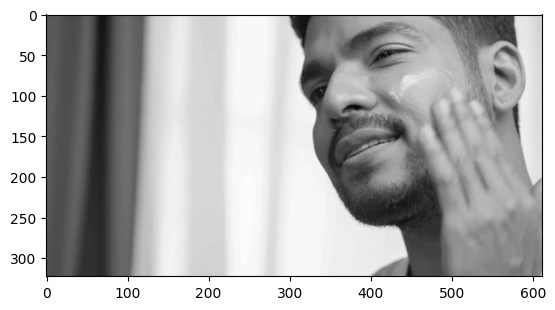

In [10]:
img = cv.imread(os.path.join(path, 'Normal', data["Normal"][0]))
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
plt.imshow(img, cmap='gray')

In [11]:
# img = cv.imread(os.path.join(path, 'Eczema', data[0][0]))
# gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
# enhanced_image = clahe.apply(gray_image)
# img_blur = cv.GaussianBlur(img, (9, 9), 10)
# alpha = 1.5  # Control the amount of sharpening
# sharpened_img = cv.addWeighted(img, 1 + alpha, img_blur, -alpha, 0)
# sharpened_color_image = cv2.cvtColor(sharpened_img, cv2.COLOR_BGR2RGB)
# resized_img = cv2.resize(sharpened_color_image,(224,224))
# plt.imshow(resized_img)  # Convert BGR to RGB for display
# plt.axis('off')  # Hide axis for a cleaner display
# plt.show()

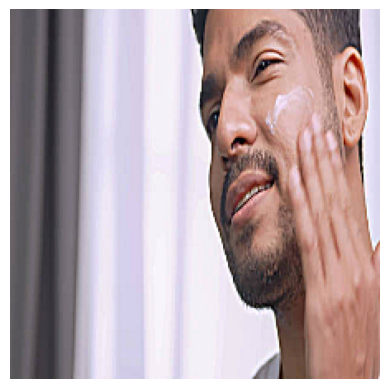

In [12]:
# Step 1: Read the original image
img = cv.imread(os.path.join(path, 'Normal', data["Normal"][0]))

# Step 2: Convert the image to grayscale for CLAHE
gray_image = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 3: Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced_image = clahe.apply(gray_image)

# Step 4: Apply Gaussian blur to the original image (not grayscale)
img_blur = cv.GaussianBlur(img, (9, 9), 10)

# Step 5: Apply Unsharp Masking for sharpening
alpha = 1.5  # Control the amount of sharpening
sharpened_img = cv.addWeighted(img, 1 + alpha, img_blur, -alpha, 0)

# No need to convert to RGB since the image is already in BGR format
# sharpened_img is already a color (BGR) image

# Step 6: Display the resulting sharpened color image
resized_img = cv.resize(sharpened_img,(224,224))
plt.imshow(cv.cvtColor(resized_img, cv.COLOR_BGR2RGB))  # Convert BGR to RGB for display
plt.axis('off')  # Hide axis for a cleaner display
plt.show()

In [13]:
def show_img(img_array):
    plt.imshow(img_array) 
    plt.axis('off')  
    plt.show()

In [14]:
def enhanced_image_process(file_path):
    kernel = np.array([[0, -1, 0],
                   [-1, 5,-1],
                   [0, -1, 0]])
    
    img = cv.imread(file_path)
    gray_image = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_image = clahe.apply(gray_image)
    
    img_blur = cv.GaussianBlur(img, (5, 5), 0)
    sharpened_img = cv.addWeighted(img, 1 + alpha, img_blur, -alpha, 0)
    resized_img = cv.resize(sharpened_img,(224,224))
    img_rgb = cv.cvtColor(resized_img, cv.COLOR_BGR2RGB)

    return img_rgb

In [15]:
def normalize_image(img_array):
    image_float = img_array.astype(np.float32)
    normalized_image = image_float / 255.0
    return normalized_image

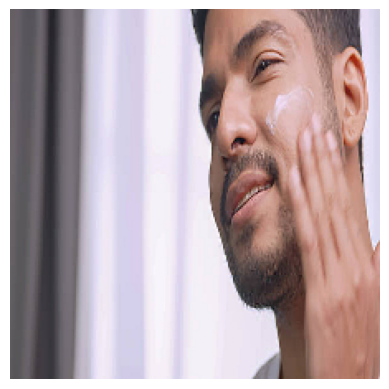

In [16]:
res = enhanced_image_process(os.path.join(path, 'Normal', data["Normal"][0]))

show_img(normalize_image(res))

In [17]:
# X = []
# Y = []
# data_count = 0
# for class_name,img_list in data.items():
#     for img in img_list:
#         img_path = os.path.join(path, class_name, img)
#         img = enhanced_image_process(img_path)
#         norm_img = normalize_image(img)
#         X.append(norm_img)
#         Y.append(label[class_name])
#         data_count = data_count + 1
# print(data_count)

In [18]:
from tqdm import tqdm
import os

X = []
Y = []
data_count = 0

# Calculate the total number of images to track progress accurately
total_images = sum(len(img_list) for img_list in data.values())

# Using tqdm for progress tracking
for class_name, img_list in tqdm(data.items(), total=len(data), desc="Processing classes"):
    for img in img_list:
        img_path = os.path.join(path, class_name, img)
        img = enhanced_image_process(img_path)
        norm_img = normalize_image(img)
        X.append(norm_img)
        Y.append(label[class_name])
        data_count += 1

print(f"Total images processed: {data_count}")


Processing classes: 100%|██████████| 5/5 [05:16<00:00, 63.20s/it]

Total images processed: 7357


In [19]:
x = np.array(X)
y = np.array(Y)

In [20]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42, shuffle=True)

In [21]:
print(len(x_train))
print(len(y_train))

print(len(x_test))
print(len(y_test))

5885
5885
1472
1472


In [22]:
# Self-attention block
def self_attention_block(input_tensor):
    channels = input_tensor.shape[-1]
    
    # Feature maps
    f = layers.Conv2D(channels // 8, (1, 1))(input_tensor)  # Shape: (None, H, W, channels/8)
    g = layers.Conv2D(channels // 8, (1, 1))(input_tensor)  # Shape: (None, H, W, channels/8)
    h = layers.Conv2D(channels, (1, 1))(input_tensor)       # Shape: (None, H, W, channels)
    
    # Reshape f and g for dot product
    f_reshaped = layers.Reshape((-1, f.shape[-1]))(f)  # Shape: (None, H*W, channels/8)
    g_reshaped = layers.Reshape((-1, g.shape[-1]))(g)  # Shape: (None, H*W, channels/8)
    
    # Compute attention map
    attention_map = layers.Dot(axes=-1)([f_reshaped, g_reshaped])  # Shape: (None, H*W, H*W)
    attention_map = layers.Softmax()(attention_map)
    
    # Reshape h for dot product
    h_reshaped = layers.Reshape((-1, h.shape[-1]))(h)  # Shape: (None, H*W, channels)

    # Output from attention
    attention_output = layers.Dot(axes=[1, 1])([attention_map, h_reshaped])  # Shape: (None, H*W, channels)
    attention_output = layers.Reshape((input_tensor.shape[1], input_tensor.shape[2], channels))(attention_output)  # Reshape back to (None, H, W, channels)

    return layers.Add()([input_tensor, attention_output])

In [23]:
# import tensorflow as tf
# from tensorflow.keras import layers, Model
# from tensorflow.keras.layers import BatchNormalization, Activation

# # Self-attention block
# def self_attention_block(input_tensor):
#     channels = input_tensor.shape[-1]
    
#     # Feature maps
#     f = layers.Conv2D(channels // 8, (1, 1))(input_tensor)  # Shape: (None, H, W, channels/8)
#     g = layers.Conv2D(channels // 8, (1, 1))(input_tensor)  # Shape: (None, H, W, channels/8)
#     h = layers.Conv2D(channels, (1, 1))(input_tensor)       # Shape: (None, H, W, channels)
    
#     # Reshape f and g for dot product
#     f_reshaped = layers.Reshape((-1, f.shape[-1]))(f)  # Shape: (None, H*W, channels/8)
#     g_reshaped = layers.Reshape((-1, g.shape[-1]))(g)  # Shape: (None, H*W, channels/8)
    
#     # Compute attention map
#     attention_map = layers.Dot(axes=-1)([f_reshaped, g_reshaped])  # Shape: (None, H*W, H*W)
#     attention_map = layers.Softmax()(attention_map)
    
#     # Reshape h for dot product
#     h_reshaped = layers.Reshape((-1, h.shape[-1]))(h)  # Shape: (None, H*W, channels)

#     # Output from attention
#     attention_output = layers.Dot(axes=[1, 1])([attention_map, h_reshaped])  # Shape: (None, H*W, channels)
#     attention_output = layers.Reshape((input_tensor.shape[1], input_tensor.shape[2], channels))(attention_output)  # Reshape back to (None, H, W, channels)

#     return layers.Add()([input_tensor, attention_output])

# # Create input tensor
# x = tf.keras.Input(shape=(224, 224, 3))
# x1 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
# x1 = BatchNormalization()(x1)
# x1 = layers.MaxPooling2D((2, 2))(x1)
# xa1 = Activation('sigmoid')(x1)

# # Apply Self-Attention Block
# attention1 = self_attention_block(xa1)

# # Create the model
# model = Model(inputs=x, outputs=attention1)

# # Compile the model
# model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# # Print model summary
# model.summary()


In [24]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, MaxPooling2D, Activation, Add, Flatten, Dense, Dropout

inputs = Input(shape=(224, 224, 3))

# First convolutional block
x1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
x1 = BatchNormalization()(x1)
x1 = MaxPooling2D((2, 2))(x1)
# xa1 = Activation('sigmoid')(x1)
attention1 = self_attention_block(x1)

# Resedual convolutional block
x2 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
x2 = MaxPooling2D((2, 2))(x2)

# Combine attention and second conv block
xa = Add()([attention1, x2])
x2 = BatchNormalization()(xa)
x2 = MaxPooling2D((2, 2))(x2)
x2 = Conv2D(32, (3, 3), activation='relu', padding='same')(x2)
# Third convolutional block
x3 = Conv2D(32, (3, 3), activation='relu', padding='same', strides=(4, 4))(inputs)
xa2 = Add()([x2, x3])
x2 = BatchNormalization()(xa2)
x3 = Conv2D(16, (3, 3), activation='relu', padding='same', strides=(2, 2))(x2)
x3 = Conv2D(8, (3, 3), activation='relu', padding='same')(x3)
x3 = MaxPooling2D((2, 2))(x3)

# Flatten and dense layers
x4 = Flatten()(x3)
x = Dense(512, activation='relu')(x4)
x = Dropout(rate=0.5)(x)
output = Dense(5, activation='sigmoid')(x)

# Create the model
customModel = Model(inputs=inputs, outputs=output)

# Compile the model
customModel.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print model summary
customModel.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │        520 │ max_pooling2d[0]… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │        520 │ max_pooling2d[0]… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 12544, 8)  │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 12544, 8)  │          0 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 12544,     │          0 │ reshape[0][0],    │
│                     │ 12544)            │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │      4,160 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 12544,     │          0 │ dot[0][0]         │
│                     │ 12544)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 12544, 64) │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_1 (Dot)         │ (None, 12544, 64) │          0 │ softmax[0][0],    │
│                     │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 112, 112,  │          0 │ dot_1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 224, 224,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 112, 112,  │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 112, 112,  │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 112, 112,  │          0 │ add[0][0],      

 Total params: 840,461 (3.21 MB)

 Trainable params: 840,141 (3.20 MB)

 Non-trainable params: 320 (1.25 KB)

In [25]:
# import tensorflow as tf
# from tensorflow.keras import layers, Model
# from tensorflow.keras.layers import BatchNormalization, Activation, Dropout, Dense, Flatten

# # Define input shape
# x = tf.keras.Input(shape=(224, 224, 3))

# # Convolutional Block 1
# x1 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
# x1 = BatchNormalization()(x1)
# x1 = layers.MaxPooling2D((2, 2))(x1)
# xa1 = Activation('sigmoid')(x1)
# attention1 = self_attention_block(xa1)  # Assuming self_attention_block is defined elsewhere

# # Convolutional Block 2
# x2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
# x2 = layers.MaxPool2D((2, 2))(x2)

# # Add attention and x2
# xa = layers.Add()([attention1, x2])
# x2 = layers.BatchNormalization()(xa)

# # Convolutional Block 3
# x3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same', strides=(2, 2))(x2)
# x3 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x3)
# x3 = layers.MaxPooling2D((2, 2))(x3)

# # Flatten and Dense Layers
# x4 = Flatten()(x3)
# x = Dense(512, activation='relu')(x4)  # Correcting the variable usage here
# x = Dropout(rate=0.5)(x)  # Use x here instead of x4
# output = Dense(5, activation='sigmoid')(x)

# # Create the model
# customModel = Model(inputs=x, outputs=output)

# # Compile the model with an appropriate loss function, optimizer, and evaluation metric
# customModel.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# # Print model summary to check the architecture
# customModel.summary()


In [26]:
customModel.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
history_customModel = customModel.fit(x_train,y_train,batch_size=4,epochs=20,validation_data=(x_test,y_test))

Epoch 1/20


I0000 00:00:1728362277.378325      73 service.cc:145] XLA service 0x7f22b000d160 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1728362277.378383      73 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


   1/1472 ━━━━━━━━━━━━━━━━━━━━ 6:31:12 16s/step - accuracy: 0.0000e+00 - loss: 2.4664

I0000 00:00:1728362288.760565      73 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_15', 32 bytes spill stores, 32 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_2', 240 bytes spill stores, 240 bytes spill loads

I0000 00:00:1728362288.774659      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1472/1472 ━━━━━━━━━━━━━━━━━━━━ 166s 102ms/step - accuracy: 0.4755 - loss: 1.2586 - val_accuracy: 0.6236 - val_loss: 0.8570
Epoch 2/20
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 141s 96ms/step - accuracy: 0.6264 - loss: 0.8235 - val_accuracy: 0.6793 - val_loss: 0.6984
Epoch 3/20
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 142s 96ms/step - accuracy: 0.6645 - loss: 0.7317 - val_accuracy: 0.5693 - val_loss: 0.8563
Epoch 4/20
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 142s 96ms/step - accuracy: 0.6989 - loss: 0.6000 - val_accuracy: 0.6923 - val_loss: 0.5675
Epoch 5/20
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 141s 96ms/step - accuracy: 0.6910 - loss: 0.5658 - val_accuracy: 0.6929 - val_loss: 0.5365
Epoch 6/20
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 142s 96ms/step - accuracy: 0.6977 - loss: 0.5290 - val_accuracy: 0.6746 - val_loss: 0.6203
Epoch 7/20
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 142s 96ms/step - accuracy: 0.7114 - loss: 0.5166 - val_accuracy: 0.6345 - val_loss: 0.7259
Epoch 8/20
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 141s 96ms/step - accuracy: 0.7023 - l

In [27]:
smxakmlmacddf

NameError: name 'smxakmlmacddf' is not defined

In [ ]:
from keras.applications.vgg16 import VGG16
base_model = VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3),
)
for layer in base_model.layers:
  layer.trainable = False

In [ ]:
x = base_model.output

# x = Dense(516, activation='relu')(x)
# x = Dropout(rate=0.5)(x)
# x = Dense(256, activation='relu')(x)
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(rate=0.5)(x)
output = Dense(5, activation='sigmoid')(x)

vgg16_model = Model(inputs = base_model.input, outputs = output)

vgg16_model.summary()

In [ ]:
vgg16_model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
history_vgg = vgg16_model.fit(x_train,y_train,batch_size=32,epochs=20,validation_data=(x_test,y_test))

In [ ]:
from sklearn.metrics import classification_report,accuracy_score
y_pred1 = vgg16_model.predict(x_test)
y_pred=np.argmax(y_pred1,axis=1)
print(classification_report(y_test,y_pred))

In [ ]:
import matplotlib.pyplot as plt
plt.title('Train_Accuracy Vs Val_Accuracy')
plt.plot(history_vgg.history['accuracy'], label='Train_Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Val_Accuracy')
plt.legend()
plt.show();

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test,y_pred)

# Create a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=['0','1','2','4'],
            yticklabels=['0','1','2','4'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
x = base_model.output

x = Flatten()(x)
x = Dense(516, activation='relu')(x)
x = Dropout(rate=0.5)(x)

x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dropout(rate=0.5)(x)

output = Dense(5, activation='sigmoid')(x)

vgg16_model2 = Model(inputs = base_model.input, outputs = output)

vgg16_model2.summary()

In [ ]:
vgg16_model2.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
history_vgg2 = vgg16_model2.fit(x_train,y_train,batch_size=32,epochs=20,validation_data=(x_test,y_test))

In [ ]:
import tensorflow as tf
base_mobnet = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    alpha=1.0,
    include_top=False,
    weights="imagenet",
)
for layer in base_mobnet.layers:
  layer.trainable = False

x = base_mobnet.output

x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(rate=0.5)(x)
output = Dense(5, activation='sigmoid')(x)

mobV2_model = Model(inputs = base_mobnet.input, outputs = output)

mobV2_model.summary()

In [ ]:
mobV2_model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
history_mobV2 = mobV2_model.fit(x_train,y_train,batch_size=32,epochs=20,validation_data=(x_test,y_test))

In [ ]:
y_pred1 = mobV2_model.predict(x_test)
y_pred=np.argmax(y_pred1,axis=1)
print(classification_report(y_test,y_pred))

# Calculate confusion matrix
cm = confusion_matrix(y_test,y_pred)

# Create a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=['0','1','2','4'],
            yticklabels=['0','1','2','4'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

plt.title('Train_Accuracy Vs Val_Accuracy MobileNetV2')
plt.plot(history_mobV2.history['accuracy'], label='Train_Accuracy')
plt.plot(history_mobV2.history['val_accuracy'], label='Val_Accuracy')
plt.legend()
plt.show();

In [ ]:
base_inceprionV3 = tf.keras.applications.InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3),
)
for layer in base_inceprionV3.layers:
  layer.trainable = False

x = base_inceprionV3.output

x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(rate=0.5)(x)

output = Dense(5, activation='sigmoid')(x)

inceprionV3_model = Model(inputs = base_inceprionV3.input, outputs = output)
inceprionV3_model.summary()

In [ ]:
inceprionV3_model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
history_inceprionV3 = inceprionV3_model.fit(x_train,y_train,batch_size=32,epochs=20,validation_data=(x_test,y_test))

In [ ]:
y_pred1 = inceprionV3_model.predict(x_test)
y_pred=np.argmax(y_pred1,axis=1)
print(classification_report(y_test,y_pred))

# Calculate confusion matrix
cm = confusion_matrix(y_test,y_pred)

# Create a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=['0','1','2','4'],
            yticklabels=['0','1','2','4'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

plt.title('Train_Accuracy Vs Val_Accuracy InceptionV3')
plt.plot(history_inceprionV3.history['accuracy'], label='Train_Accuracy')
plt.plot(history_inceprionV3.history['val_accuracy'], label='Val_Accuracy')
plt.legend()
plt.show();

In [ ]:
base_convNext = tf.keras.applications.ConvNeXtBase(
    model_name="convnext_base",
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3),
    pooling=None,
    classes=3,
    classifier_activation="softmax",
)
for layer in base_convNext.layers:
  layer.trainable = False

x = base_convNext.output

x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(rate=0.5)(x)

output = Dense(5, activation='sigmoid')(x)

convNext_model = Model(inputs = base_convNext.input, outputs = output)
convNext_model.summary()

In [ ]:
convNext_model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
history_convNext = convNext_model.fit(x_train,y_train,batch_size=32,epochs=20,validation_data=(x_test,y_test))

In [ ]:
y_pred1 = convNext_model.predict(x_test)
y_pred=np.argmax(y_pred1,axis=1)
print(classification_report(y_test,y_pred))

# Calculate confusion matrix
cm = confusion_matrix(y_test,y_pred)

# Create a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=['0','1','2','4'],
            yticklabels=['0','1','2','4'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

plt.title('Train_Accuracy Vs Val_Accuracy ConvNext')
plt.plot(history_convNext.history['accuracy'], label='Train_Accuracy')
plt.plot(history_convNext.history['val_accuracy'], label='Val_Accuracy')
plt.legend()
plt.show();